Parámetros REALES usados para generar los datos:
  β0 real   = 3
  β1 real   = 2
  σ (ruido) = 3.0

Media de x (x̄): 4.7018
Media de y (ȳ): 12.4004
Varianza de x: 876.1495
Varianza de y: 3763.7970

Sxx: 876.1495
Sxy: 1631.4500
β̂0 (intersección): 3.6453  (real: 3)
β̂1 (pendiente):    1.8621  (real: 2)

SST: 3763.7970
SSR: 3037.8709
SSE: 725.9261
R²:  0.8071
MSE: 7.2593

σ̂² (varianza del error): 7.4074  (real σ²=9.0)
σ̂  (desviación estándar residual): 2.7217  (real σ=3.0)


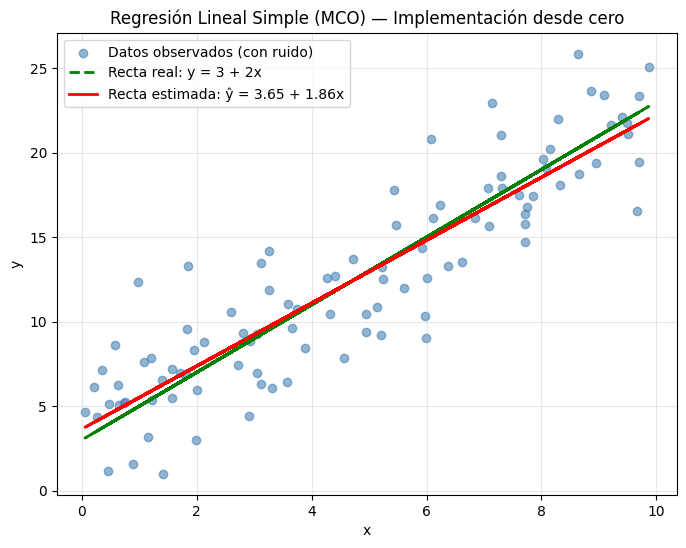


Media de los residuos: 0.000000  (debe ser ≈ 0)
Desviación estándar de los residuos: 2.7079


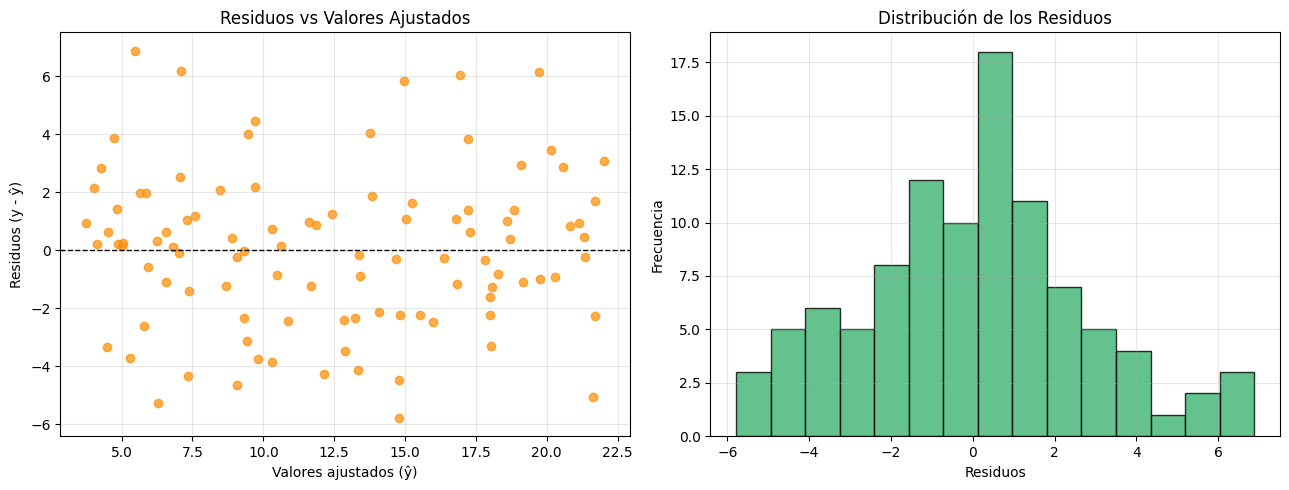

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PASO 1: Generar dataset sintético  y = 2x + 3 + ruido
# ==========================================================
np.random.seed(42)

n = 100
beta0_real = 3
beta1_real = 2
ruido_sigma = 3.0

x = np.random.rand(n) * 10

y_determinista = beta0_real + beta1_real * x
ruido = np.random.randn(n) * ruido_sigma
y = y_determinista + ruido

print("Parámetros REALES usados para generar los datos:")
print(f"  β0 real   = {beta0_real}")
print(f"  β1 real   = {beta1_real}")
print(f"  σ (ruido) = {ruido_sigma}")

# ==========================================================
# PASO 2: Calcular la varianza
# Se calcula como suma de cuadrados de las desviaciones respecto
# a la media, sin dividir entre nada. Esta cantidad no necesita el
# modelo todavía (solo depende de los datos), así que sí se puede
# calcular en este punto, antes de hacer MCO:
#   - var_x es el mismo Sxx que se usa después en el Paso 3
#   - var_y es el mismo SST que se usa después en el Paso 4
# ==========================================================
x_barra = np.sum(x) / n
y_barra = np.sum(y) / n

var_x = np.sum((x - x_barra) ** 2)
var_y = np.sum((y - y_barra) ** 2)

print(f"\nMedia de x (x̄): {x_barra:.4f}")
print(f"Media de y (ȳ): {y_barra:.4f}")
print(f"Varianza de x: {var_x:.4f}")
print(f"Varianza de y: {var_y:.4f}")

# ==========================================================
# PASO 3: Calcular β̂0 y β̂1 usando MCO
# ==========================================================
Sxx = var_x   # ya lo calculamos en el Paso 2
Sxy = 0
for i in range(n):
    Sxy += (x[i] - x_barra) * (y[i] - y_barra)

beta1_hat = Sxy / Sxx
beta0_hat = y_barra - beta1_hat * x_barra

print(f"\nSxx: {Sxx:.4f}")
print(f"Sxy: {Sxy:.4f}")
print(f"β̂0 (intersección): {beta0_hat:.4f}  (real: {beta0_real})")
print(f"β̂1 (pendiente):    {beta1_hat:.4f}  (real: {beta1_real})")

# ==========================================================
# PASO 4: Calcular R² y MSE
# ==========================================================
y_pred = np.zeros(n)
for i in range(n):
    y_pred[i] = beta0_hat + beta1_hat * x[i]

SST = var_y   # ya lo calculamos en el Paso 2
SSR = 0
SSE = 0

for i in range(n):
    SSR += (y_pred[i] - y_barra) ** 2
    SSE += (y[i] - y_pred[i]) ** 2

r2 = SSR / SST
mse = SSE / n

print(f"\nSST: {SST:.4f}")
print(f"SSR: {SSR:.4f}")
print(f"SSE: {SSE:.4f}")
print(f"R²:  {r2:.4f}")
print(f"MSE: {mse:.4f}")

# ==========================================================
# EXTRA: Varianza del error σ̂²
# A diferencia de la varianza del Paso 2, ésta SÍ necesita el
# modelo ya ajustado (usa SSE, que depende de β̂0 y β̂1), por eso
# solo se puede calcular hasta aquí, no antes.
# ==========================================================
p = 1
sigma2_hat = SSE / (n - p - 1)
sigma_hat = np.sqrt(sigma2_hat)

print(f"\nσ̂² (varianza del error): {sigma2_hat:.4f}  (real σ²={ruido_sigma**2})")
print(f"σ̂  (desviación estándar residual): {sigma_hat:.4f}  (real σ={ruido_sigma})")

# ==========================================================
# PASO 5: Visualizar resultados
# ==========================================================
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='steelblue', alpha=0.6, label='Datos observados (con ruido)')
plt.plot(x, y_determinista, color='green', linewidth=2, linestyle='--',
         label=f'Recta real: y = {beta0_real} + {beta1_real}x')
plt.plot(x, y_pred, color='red', linewidth=2,
         label=f'Recta estimada: ŷ = {beta0_hat:.2f} + {beta1_hat:.2f}x')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regresión Lineal Simple (MCO) — Implementación desde cero')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==========================================================
# PASO 6: Gráfico de residuos
# ==========================================================
residuos = y - y_pred

print(f"\nMedia de los residuos: {np.mean(residuos):.6f}  (debe ser ≈ 0)")
print(f"Desviación estándar de los residuos: {np.std(residuos, ddof=1):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred, residuos, color='darkorange', alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Valores ajustados (ŷ)')
axes[0].set_ylabel('Residuos (y - ŷ)')
axes[0].set_title('Residuos vs Valores Ajustados')
axes[0].grid(alpha=0.3)

axes[1].hist(residuos, bins=15, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Residuos')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de los Residuos')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()